<div id="top-jl-7-canonicalproblems"></div>

<div align="center">
  <h1>Three Canonical QUBO Starter Problems</h1>
  <p>Original Julia derivations and independent checks for number partitioning, Max-Cut, and minimum vertex cover.</p>
  <b>Maintained by the <a href="https://github.com/JuliaQUBO">JuliaQUBO</a> organization</b>
  <br>
  <a href="https://secquoia.github.io/">SECQUOIA</a> &nbsp;&middot;&nbsp; <a href="https://www.psr-inc.com/">PSR Energy</a>
  <br>
  <br>
  <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/7-CanonicalProblems.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

## Setup

### Local installation

From the repository root, instantiate the shared Julia environment before opening this notebook:

    julia --project=notebooks_jl -e 'using Pkg; Pkg.instantiate()'

After that one-time environment step, every example below is credential-free and uses no network service.

### Google Colab

Open the badge above, select a Julia runtime, and run the setup cells. The bootstrap clones this repository only when Colab does not already have it, then activates the same checked-in notebook project used locally.

In [1]:
function load_qubonotebooks_bootstrap()
    candidates = (
        joinpath(pwd(), "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "..", "scripts", "notebook_bootstrap.jl"),
        joinpath(pwd(), "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
        joinpath("/content", "QUBONotebooks", "scripts", "notebook_bootstrap.jl"),
    )

    for candidate in candidates
        if isfile(candidate)
            include(candidate)
            return nothing
        end
    end

    in_colab = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP") || isdir(joinpath("/content", "sample_data"))
    if in_colab
        repo_dir = get(ENV, "QUBONOTEBOOKS_REPO_DIR", joinpath(pwd(), "QUBONotebooks"))
        if !isdir(repo_dir)
            println("[bootstrap] Cloning JuliaQUBO/QUBONotebooks into $repo_dir")
            run(Cmd(["git", "clone", "--quiet", "--depth", "1", "https://github.com/JuliaQUBO/QUBONotebooks.git", repo_dir]))
        end
        include(joinpath(repo_dir, "scripts", "notebook_bootstrap.jl"))
        return nothing
    end

    error("Could not locate scripts/notebook_bootstrap.jl from $(pwd()).")
end

load_qubonotebooks_bootstrap()

BOOTSTRAP = Base.invokelatest(QUBONotebooksBootstrap.bootstrap_notebook, "7-CanonicalProblems")
QUBONOTEBOOKS_REPO_DIR = BOOTSTRAP.repo_dir
JULIA_NOTEBOOKS_DIR = BOOTSTRAP.notebooks_dir
JULIA_PROJECT_DIR = BOOTSTRAP.project_dir
IN_COLAB = BOOTSTRAP.in_colab;

In [2]:
import Pkg

python_warning_filter = "ignore:invalid escape sequence:SyntaxWarning"
python_warning_filters = String.(filter(!isempty, split(get(ENV, "PYTHONWARNINGS", ""), ",")))
if python_warning_filter ∉ python_warning_filters
    push!(python_warning_filters, python_warning_filter)
    ENV["PYTHONWARNINGS"] = join(python_warning_filters, ",")
end

if @isdefined(JULIA_PROJECT_DIR)
    Pkg.activate(JULIA_PROJECT_DIR; io = devnull)
else
    Pkg.activate(@__DIR__; io = devnull)
end
Pkg.instantiate(; io = devnull, allow_autoprecomp = false)

## Learning objectives

By the end of this notebook you will be able to:

1. derive QUBOs for number partitioning, Max-Cut, and minimum vertex cover;
2. distinguish raw QUBO energy from the corresponding application score;
3. verify every binary state against an independently implemented scoring function; and
4. decode all exact optima and explain complementary or symmetric degeneracy.

## Prerequisites

**Prior notebooks:** Notebook 2 introduces JuMP and QUBO models; this notebook is also self-contained.

**Mathematical background:** Binary variables, finite sums, and basic graph terminology.

**Software:** Julia 1.10+ with the shared notebook project instantiated.

**Accounts required:** None.

In [3]:
# QUBONOTEBOOKS_COLAB_IMPORT_CELL
Base.invokelatest(
    QUBONotebooksBootstrap.warm_notebook_packages!,
    "7-CanonicalProblems",
);

Plots.default(; size = (640, 420), legend = false)


## Verification strategy

Each section first defines an application-level score that does not inspect a JuMP model. We then enumerate all states, evaluate the actual expanded JuMP objective (including its constant), and compare the two values. Finally, QUBO.ExactSampler independently enumerates the model so that its best energy and complete optimal-state degeneracy can be compared with our application enumeration. Every JuMP model is a minimization model.

In [4]:
function all_binary_states(n::Integer)
    states = Vector{Vector{Int}}()
    for state in Iterators.product(ntuple(_ -> (0, 1), n)...)
        push!(states, collect(state))
    end
    return states
end

function evaluate_jump_objective(model::Model, variables, bits)
    assignment = Dict(variables[i] => Float64(bits[i]) for i in eachindex(variables))
    return JuMP.value(variable -> assignment[variable], JuMP.objective_function(model))
end

function assert_all_states_match(model::Model, variables, analytic_objective; atol = 1e-9)
    @assert JuMP.objective_sense(model) == JuMP.MOI.MIN_SENSE
    states = all_binary_states(length(variables))
    for bits in states
        jump_value = evaluate_jump_objective(model, variables, bits)
        analytic_value = analytic_objective(bits)
        @assert isapprox(jump_value, analytic_value; atol = atol, rtol = 0)
    end
    return states
end

function exact_sampler_optima!(model::Model, variables; atol = 1e-9)
    set_optimizer(model, QUBO.ExactSampler.Optimizer)
    optimize!(model)
    @assert termination_status(model) in (JuMP.MOI.OPTIMAL, JuMP.MOI.LOCALLY_SOLVED)

    energies = [objective_value(model; result = result) for result in 1:result_count(model)]
    best_energy = minimum(energies)
    optima = [
        round.(Int, value.(variables; result = result))
        for result in eachindex(energies)
        if isapprox(energies[result], best_energy; atol = atol, rtol = 0)
    ]
    return best_energy, optima
end

same_states(left, right) = Set(Tuple.(left)) == Set(Tuple.(right))

same_states (generic function with 1 method)

## Number partitioning

Given positive weights $a_1,\ldots,a_n$, divide them into two groups whose sums are as close as possible. Let $x_i=0$ place item $i$ in group A and $x_i=1$ place it in group B. We use the explicit spin/bit convention

$$s_i = 1 - 2x_i,$$

so the signed imbalance is

$$I(x)=\sum_i a_i s_i=A-2\sum_i a_i x_i,\qquad A=\sum_i a_i.$$

Minimizing its square produces the QUBO

$$E_{\mathrm{NP}}(x)=A^2+\sum_i(4a_i^2-4Aa_i)x_i+8\sum_{i<j}a_i a_jx_ix_j.$$

The raw energy is the squared signed imbalance; the application score reported below is the absolute imbalance.

In [5]:
partition_weights = [1, 3, 4, 8]

partition_signed_imbalance(weights, bits) =
    sum(weights[i] * (1 - 2 * bits[i]) for i in eachindex(weights))

partition_imbalance(weights, bits) = abs(partition_signed_imbalance(weights, bits))
partition_energy(weights, bits) = partition_signed_imbalance(weights, bits)^2

function decode_partition(weights, bits)
    group_a = weights[findall(==(0), bits)]
    group_b = weights[findall(==(1), bits)]
    return group_a, group_b
end

decode_partition (generic function with 1 method)

In [6]:
partition_model = Model()
@variable(partition_model, partition_x[1:length(partition_weights)], Bin)
@objective(
    partition_model,
    Min,
    (sum(partition_weights[i] * (1 - 2 * partition_x[i]) for i in eachindex(partition_weights)))^2,
)

4 partition_x[1]² + 24 partition_x[2]*partition_x[1] + 32 partition_x[3]*partition_x[1] + 64 partition_x[4]*partition_x[1] + 36 partition_x[2]² + 96 partition_x[3]*partition_x[2] + 192 partition_x[4]*partition_x[2] + 64 partition_x[3]² + 256 partition_x[4]*partition_x[3] + 256 partition_x[4]² - 64 partition_x[1] - 192 partition_x[2] - 256 partition_x[3] - 512 partition_x[4] + 256

In [7]:
partition_states = assert_all_states_match(
    partition_model,
    partition_x,
    bits -> partition_energy(partition_weights, bits),
)
partition_energies = [partition_energy(partition_weights, bits) for bits in partition_states]
partition_best_energy = minimum(partition_energies)
partition_optima = partition_states[findall(==(partition_best_energy), partition_energies)]

partition_exact_energy, partition_exact_optima = exact_sampler_optima!(partition_model, partition_x)
@assert partition_best_energy == 0
@assert isapprox(partition_exact_energy, partition_best_energy; atol = 1e-9)
@assert same_states(partition_exact_optima, partition_optima)
@assert length(partition_optima) == 2
@assert all(partition_imbalance(partition_weights, bits) == 0 for bits in partition_optima)

for bits in partition_optima
    group_a, group_b = decode_partition(partition_weights, bits)
    println("x=$bits: A=$group_a, B=$group_b, imbalance=$(partition_imbalance(partition_weights, bits)), raw energy=$(partition_energy(partition_weights, bits))")
end

x=[1, 1, 1, 0]: A=[8], B=[1, 3, 4], imbalance=0, raw energy=0
x=[0, 0, 0, 1]: A=[1, 3, 4], B=[8], imbalance=0, raw energy=0


The two optimal bit strings are complements: one names $\{1,3,4\}$ as group A and $\{8\}$ as group B, while the other swaps the labels. They represent the same unlabeled partition, each with application imbalance 0 and raw QUBO energy 0.

## Max-Cut

Let $x_i\in\{0,1\}$ label the side of a cut containing vertex $i$. For an edge $(i,j)$, the expression

$$x_i+x_j-2x_ix_j$$

is 1 exactly when the endpoints are separated. Thus the cut weight is

$$C(x)=\sum_{(i,j)\in E}w_{ij}(x_i+x_j-2x_ix_j).$$

Max-Cut maximizes $C$. QUBO solvers minimize, so our raw QUBO energy is explicitly $E_{\mathrm{MC}}(x)=-C(x)$.

In [8]:
weighted_edges = [
    (1, 2, 2),
    (1, 3, 1),
    (2, 3, 2),
    (2, 4, 1),
    (3, 4, 3),
]

maxcut_weight(edges, bits) =
    sum(bits[i] == bits[j] ? 0 : weight for (i, j, weight) in edges)

maxcut_energy(edges, bits) = -maxcut_weight(edges, bits)

function decode_cut(bits)
    side_zero = findall(==(0), bits)
    side_one = findall(==(1), bits)
    return side_zero, side_one
end

decode_cut (generic function with 1 method)

In [9]:
maxcut_model = Model()
@variable(maxcut_model, maxcut_x[1:4], Bin)
@objective(
    maxcut_model,
    Min,
    -sum(
        weight * (maxcut_x[i] + maxcut_x[j] - 2 * maxcut_x[i] * maxcut_x[j])
        for (i, j, weight) in weighted_edges
    ),
)

4 maxcut_x[1]*maxcut_x[2] + 2 maxcut_x[1]*maxcut_x[3] + 4 maxcut_x[2]*maxcut_x[3] + 2 maxcut_x[2]*maxcut_x[4] + 6 maxcut_x[3]*maxcut_x[4] - 3 maxcut_x[1] - 5 maxcut_x[2] - 6 maxcut_x[3] - 4 maxcut_x[4]

In [10]:
maxcut_states = assert_all_states_match(
    maxcut_model,
    maxcut_x,
    bits -> maxcut_energy(weighted_edges, bits),
)
maxcut_energies = [maxcut_energy(weighted_edges, bits) for bits in maxcut_states]
maxcut_best_energy = minimum(maxcut_energies)
maxcut_optima = maxcut_states[findall(==(maxcut_best_energy), maxcut_energies)]

maxcut_exact_energy, maxcut_exact_optima = exact_sampler_optima!(maxcut_model, maxcut_x)
@assert maxcut_best_energy == -7
@assert isapprox(maxcut_exact_energy, maxcut_best_energy; atol = 1e-9)
@assert same_states(maxcut_exact_optima, maxcut_optima)
@assert length(maxcut_optima) == 4
@assert all(maxcut_weight(weighted_edges, bits) == 7 for bits in maxcut_optima)

for bits in maxcut_optima
    side_zero, side_one = decode_cut(bits)
    println("x=$bits: S0=$side_zero, S1=$side_one, cut weight=$(maxcut_weight(weighted_edges, bits)), raw energy=$(maxcut_energy(weighted_edges, bits))")
end

x=[1, 0, 1, 0]: S0=[2, 4], S1=[1, 3], cut weight=7, raw energy=-7
x=[0, 1, 1, 0]: S0=[1, 4], S1=[2, 3], cut weight=7, raw energy=-7
x=[1, 0, 0, 1]: S0=[2, 3], S1=[1, 4], cut weight=7, raw energy=-7
x=[0, 1, 0, 1]: S0=[1, 3], S1=[2, 4], cut weight=7, raw energy=-7


There are four optimal labeled bit strings. Complementing every bit swaps the two side labels without changing the cut, so the four strings form two complementary pairs. The application optimum is a cut weight of 7; the corresponding minimized QUBO energy is -7.

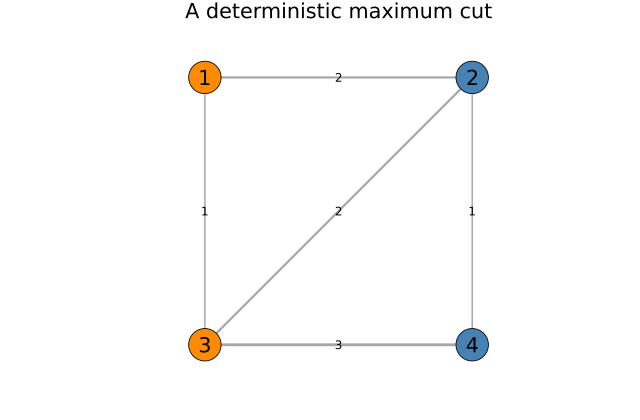

In [11]:
fixed_positions = Dict(
    1 => (-1.0, 1.0),
    2 => (1.0, 1.0),
    3 => (-1.0, -1.0),
    4 => (1.0, -1.0),
)
representative_cut = first(maxcut_optima)
cut_plot = plot(; xlims = (-1.35, 1.35), ylims = (-1.35, 1.35), aspect_ratio = :equal, framestyle = :none, title = "A deterministic maximum cut")

for (i, j, weight) in weighted_edges
    x_coordinates = [fixed_positions[i][1], fixed_positions[j][1]]
    y_coordinates = [fixed_positions[i][2], fixed_positions[j][2]]
    plot!(cut_plot, x_coordinates, y_coordinates; color = :gray65, linewidth = 0.8 + 0.7 * weight)
    annotate!(cut_plot, sum(x_coordinates) / 2, sum(y_coordinates) / 2, text(string(weight), 8, :black))
end

node_x = [fixed_positions[i][1] for i in 1:4]
node_y = [fixed_positions[i][2] for i in 1:4]
node_colors = [bit == 0 ? :steelblue : :darkorange for bit in representative_cut]
scatter!(cut_plot, node_x, node_y; markersize = 18, markercolor = node_colors, markerstrokecolor = :black, series_annotations = string.(1:4))
cut_plot

## Minimum vertex cover

A vertex cover selects vertices so every edge has at least one selected endpoint. With $x_i=1$ meaning selected, edge $(i,j)$ is uncovered exactly when $(1-x_i)(1-x_j)=1$. The penalized QUBO is

$$E_{\mathrm{VC}}(x)=\sum_i x_i+P\sum_{(i,j)\in E}(1-x_i)(1-x_j).$$

For this unweighted objective, $P=2$ is sufficient: if an edge is uncovered, selecting either endpoint increases the cover size by at most 1 and removes at least one penalty of 2. Therefore repairing an uncovered edge strictly reduces the objective; no infeasible state can be optimal. This is a proof-based choice, not a trial-and-error parameter.

In [12]:
cover_edges = [(1, 2), (1, 3), (2, 3), (3, 4)]
cover_penalty = 2

uncovered_cover_edges(edges, bits) =
    [(i, j) for (i, j) in edges if bits[i] == 0 && bits[j] == 0]

cover_size(bits) = sum(bits)
cover_energy(edges, penalty, bits) =
    cover_size(bits) + penalty * length(uncovered_cover_edges(edges, bits))

selected_vertices(bits) = findall(==(1), bits)

selected_vertices (generic function with 1 method)

In [13]:
cover_model = Model()
@variable(cover_model, cover_x[1:4], Bin)
@objective(
    cover_model,
    Min,
    sum(cover_x) + cover_penalty * sum((1 - cover_x[i]) * (1 - cover_x[j]) for (i, j) in cover_edges),
)

2 cover_x[1]*cover_x[2] + 2 cover_x[1]*cover_x[3] + 2 cover_x[2]*cover_x[3] + 2 cover_x[3]*cover_x[4] - 3 cover_x[1] - 3 cover_x[2] - 5 cover_x[3] - cover_x[4] + 8

In [14]:
cover_states = assert_all_states_match(
    cover_model,
    cover_x,
    bits -> cover_energy(cover_edges, cover_penalty, bits),
)
cover_energies = [cover_energy(cover_edges, cover_penalty, bits) for bits in cover_states]
cover_best_energy = minimum(cover_energies)
cover_optima = cover_states[findall(==(cover_best_energy), cover_energies)]

cover_exact_energy, cover_exact_optima = exact_sampler_optima!(cover_model, cover_x)
@assert cover_best_energy == 2
@assert isapprox(cover_exact_energy, cover_best_energy; atol = 1e-9)
@assert same_states(cover_exact_optima, cover_optima)
@assert length(cover_optima) == 2
@assert all(isempty(uncovered_cover_edges(cover_edges, bits)) for bits in cover_optima)
@assert all(cover_size(bits) == 2 for bits in cover_optima)

for bits in cover_optima
    println("x=$bits: selected=$(selected_vertices(bits)), uncovered=$(uncovered_cover_edges(cover_edges, bits)), raw energy=$(cover_energy(cover_edges, cover_penalty, bits))")
end

x=[1, 0, 1, 0]: selected=[1, 3], uncovered=Tuple{Int64, Int64}[], raw energy=2
x=[0, 1, 1, 0]: selected=[2, 3], uncovered=Tuple{Int64, Int64}[], raw energy=2


The two minimum covers are $\{1,3\}$ and $\{2,3\}$. Every edge is checked directly, both covers have application size 2, and their raw penalized energy is also 2 because no penalty remains.

## Practice checkpoints

1. Change the partition weights to $[1,2,3,7]$. Before running the model, predict the minimum absolute imbalance and whether complement symmetry still doubles the labeled degeneracy.
2. Add edge $(1,4)$ with weight 2 to the Max-Cut instance. Recompute the direct cut scores and explain any change in degeneracy.
3. Replace $P=2$ by $P=1$ in the vertex-cover model. Find an infeasible state tied with a feasible optimum and explain why the strict inequality $P>1$ matters.

For each change, rerun the all-state assertion before trusting the solver output.

In [15]:
# EXERCISE 1: Predict the best imbalance and labeled degeneracy for [1, 2, 3, 7].
# Then use all_binary_states and partition_imbalance to check your prediction.
nothing

In [16]:
# SOLUTION (hidden in workshop version):
practice_partition_weights = [1, 2, 3, 7]
practice_partition_states = all_binary_states(length(practice_partition_weights))
practice_partition_scores = [partition_imbalance(practice_partition_weights, bits) for bits in practice_partition_states]
practice_partition_best = minimum(practice_partition_scores)
practice_partition_optima = practice_partition_states[findall(==(practice_partition_best), practice_partition_scores)]
@assert practice_partition_best == 1
@assert length(practice_partition_optima) == 2
println("Best imbalance: $practice_partition_best; labeled optima: $practice_partition_optima")

Best imbalance: 1; labeled optima: [[1, 1, 1, 0], [0, 0, 0, 1]]


In [17]:
# EXERCISE 2: Add weighted edge (1, 4, 2), then recompute the best cut weight and degeneracy.
nothing

In [18]:
# SOLUTION (hidden in workshop version):
practice_weighted_edges = [weighted_edges; (1, 4, 2)]
practice_maxcut_states = all_binary_states(4)
practice_maxcut_scores = [maxcut_weight(practice_weighted_edges, bits) for bits in practice_maxcut_states]
practice_maxcut_best = maximum(practice_maxcut_scores)
practice_maxcut_optima = practice_maxcut_states[findall(==(practice_maxcut_best), practice_maxcut_scores)]
println("Best cut weight: $practice_maxcut_best; labeled optima: $practice_maxcut_optima")

Best cut weight: 9; labeled optima: [[1, 0, 1, 0], [0, 1, 0, 1]]


In [19]:
# EXERCISE 3: Set the cover penalty to 1 and find an infeasible state tied at the best energy.
nothing

In [20]:
# SOLUTION (hidden in workshop version):
weak_cover_penalty = 1
weak_cover_states = all_binary_states(4)
weak_cover_energies = [cover_energy(cover_edges, weak_cover_penalty, bits) for bits in weak_cover_states]
weak_cover_best = minimum(weak_cover_energies)
weak_cover_optima = weak_cover_states[findall(==(weak_cover_best), weak_cover_energies)]
weak_cover_infeasible_optima = [bits for bits in weak_cover_optima if !isempty(uncovered_cover_edges(cover_edges, bits))]
@assert !isempty(weak_cover_infeasible_optima)
println("With P=1, infeasible best-energy states include $weak_cover_infeasible_optima")

With P=1, infeasible best-energy states include [[0, 0, 1, 0]]


## Summary

**Learning objectives met:**

- Number partitioning minimizes a squared signed imbalance; its raw energy is the square of the application imbalance.
- Max-Cut is a maximization problem, so its cut weight enters the minimized QUBO with a negative sign.
- Minimum vertex cover combines cardinality with an uncovered-edge penalty; a penalty strictly larger than one is sufficient here.
- Exhaustive application scoring, full JuMP-objective evaluation, and ExactSampler agree for every example.
- Complementary partition and cut bit strings can encode equivalent unlabeled solutions.

**Next steps:** Use the practice checkpoints to change one instance at a time while keeping the all-state assertions green.

**Further reading:**

- The Five Starter Problems paper develops the application context for these formulations.
- The QUBO.jl documentation describes the public modeling and sampling interfaces used here.

## References

1. A. R. Mazumder and S. Tayur, *Five Starter Problems: Solving Quadratic Unconstrained Binary Optimization Models on Quantum Computers*, TutORials in Operations Research (2025), pp. 145–183, https://doi.org/10.1287/educ.2025.0288.
2. Companion materials: https://github.com/arulrhikm/Solving-QUBOs-on-Quantum-Computers.
3. QUBO.jl public API and ExactSampler: https://github.com/JuliaQUBO/QUBO.jl.

This notebook contains original Julia code, examples, prose, and figures. The companion repository is cited as context; no source cells, prose, saved output, or assets were copied from it.